# Servo J 위치/속도/가속도 프로파일 확인

`move_servo_j`로 base joint를 0도에서 90도까지 움직이면서 `jnt_ref`를 기록하고, 위치를 수치 미분해서 속도/가속도 그래프를 그립니다.

- `jnt_ref`: 제어기 reference joint position
- 마지막 `move_servo_j` 명령을 보낸 시점은 그래프에 세로선으로 표시합니다.

In [37]:
import time
import threading

import numpy as np
import matplotlib.pyplot as plt
import rbpodo as rb

plt.rcParams.update({"font.size": 12})

## 설정

`REAL_MODE = True`로 바꾸면 실제 로봇 모드로 실행합니다. 먼저 작은 각도/낮은 속도로 확인한 뒤 키우는 것을 권장합니다.

In [38]:
ROBOT_IP = "10.0.2.7"
REAL_MODE = False

JOINT_INDEX = 0       # 0=base, 1=shoulder, ...
START_DEG = 0.0
END_DEG = 90.0
N_STEPS = 1000
SERVO_DT = 0.005      # move_servo_j command period

T1 = 0.01
T2 = 0.1
GAIN = 0.5
ALPHA = 0.5

RECORD_HZ = 100.0
PRE_RECORD_S = 0.5
POST_RECORD_S = 0.8

## 기록 헬퍼

`CobotData.request_data()`로 별도 thread에서 `jnt_ref`를 기록합니다.

In [39]:
def check_response(rc):
    rc.error().throw_if_not_empty()
    if hasattr(rc, "clear"):
        rc.clear()


def wait_for_motion(robot, rc, start_timeout=2.0, finish_timeout=60.0):
    started = robot.wait_for_move_started(rc, start_timeout)
    if started.type() == rb.ReturnType.Success:
        robot.wait_for_move_finished(rc, finish_timeout)
    check_response(rc)


def record_loop(robot_ip, records, stop_event, hz=100.0, timing_info=None):
    data_channel = rb.CobotData(robot_ip)
    period = 1.0 / hz
    t0 = time.perf_counter()
    if timing_info is not None:
        timing_info["record_t0"] = t0
    while not stop_event.is_set():
        loop_t = time.perf_counter()
        try:
            data = data_channel.request_data(0.5)
            if data is not None:
                records.append({
                    "t": time.perf_counter() - t0,
                    "jnt_ref": np.array(data.sdata.jnt_ref, dtype=float),
                })
        except Exception:
            pass

        elapsed = time.perf_counter() - loop_t
        time.sleep(max(0.0, period - elapsed))


def sleep_until(target_time):
    dt = target_time - time.perf_counter()
    if dt > 0:
        time.sleep(dt)

## 실행 및 기록

아래 셀을 실행하면 로봇이 움직입니다. `REAL_MODE` 설정을 반드시 확인하세요.

In [ ]:
records = []
timing_info = {}
stop_event = threading.Event()
record_thread = threading.Thread(
    target=record_loop,
    args=(ROBOT_IP, records, stop_event, RECORD_HZ, timing_info),
    daemon=True,
)

robot = rb.Cobot(ROBOT_IP)
rc = rb.ResponseCollector()

mode = rb.OperationMode.Real if REAL_MODE else rb.OperationMode.Simulation
robot.set_operation_mode(rc, mode)
robot.set_speed_bar(rc, 1.0)
robot.flush(rc)
check_response(rc)

home = np.zeros(6, dtype=float)
home[JOINT_INDEX] = START_DEG

print("move to start:", home.tolist())
robot.move_j(rc, home, 50, 100)
wait_for_motion(robot, rc)

record_thread.start()
time.sleep(PRE_RECORD_S)

print("start servo_j stream")
robot.disable_waiting_ack(rc)
t_stream_start = time.perf_counter()
last_servo_command_perf = None

T1 = 0.01
T2 = 0.2
GAIN = 1
ALPHA = 0.5

try:
    for i in range(N_STEPS + 1):
        ratio = i / N_STEPS
        q = np.zeros(6, dtype=float)
        q[JOINT_INDEX] = START_DEG + ratio * (END_DEG - START_DEG)
        robot.move_servo_j(rc, q, T1, T2, GAIN, ALPHA)
        last_servo_command_perf = time.perf_counter()
        sleep_until(t_stream_start + (i + 1) * SERVO_DT)

    # robot.move_speed_j(rc, q, T1, T2, GAIN, ALPHA)
finally:
    robot.enable_waiting_ack(rc)

robot.wait_for_move_finished(rc, 60.0)
check_response(rc)
time.sleep(POST_RECORD_S)

stop_event.set()
record_thread.join(timeout=2.0)

record_t0 = timing_info.get("record_t0")
last_servo_command_time = None if record_t0 is None or last_servo_command_perf is None else last_servo_command_perf - record_t0

print(f"records: {len(records)}")
if last_servo_command_time is not None:
    print(f"last servo_j command: {last_servo_command_time:.3f} s")

move to start: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
start servo_j stream
records: 646
last servo_j command: 5.502 s


## 위치/속도/가속도 계산

`np.gradient`로 위치를 한 번 미분해 속도, 두 번 미분해 가속도를 계산합니다.

In [49]:
if len(records) < 3:
    raise RuntimeError("Not enough records. Check robot connection or RECORD_HZ.")

t = np.array([r["t"] for r in records], dtype=float)
q_ref_all = np.array([r["jnt_ref"] for r in records], dtype=float)

q_ref = q_ref_all[:, JOINT_INDEX]

v_ref = np.gradient(q_ref, t)
a_ref = np.gradient(v_ref, t)

print(f"duration: {t[-1] - t[0]:.3f} s")
print(f"ref peak velocity: {np.nanmax(np.abs(v_ref)):.3f} deg/s")
print(f"ref peak acceleration: {np.nanmax(np.abs(a_ref)):.3f} deg/s^2")
if last_servo_command_time is not None:
    print(f"last servo_j command: {last_servo_command_time:.3f} s")

duration: 6.399 s
ref peak velocity: 21.694 deg/s
ref peak acceleration: 429.493 deg/s^2
last servo_j command: 5.501 s


## 그래프

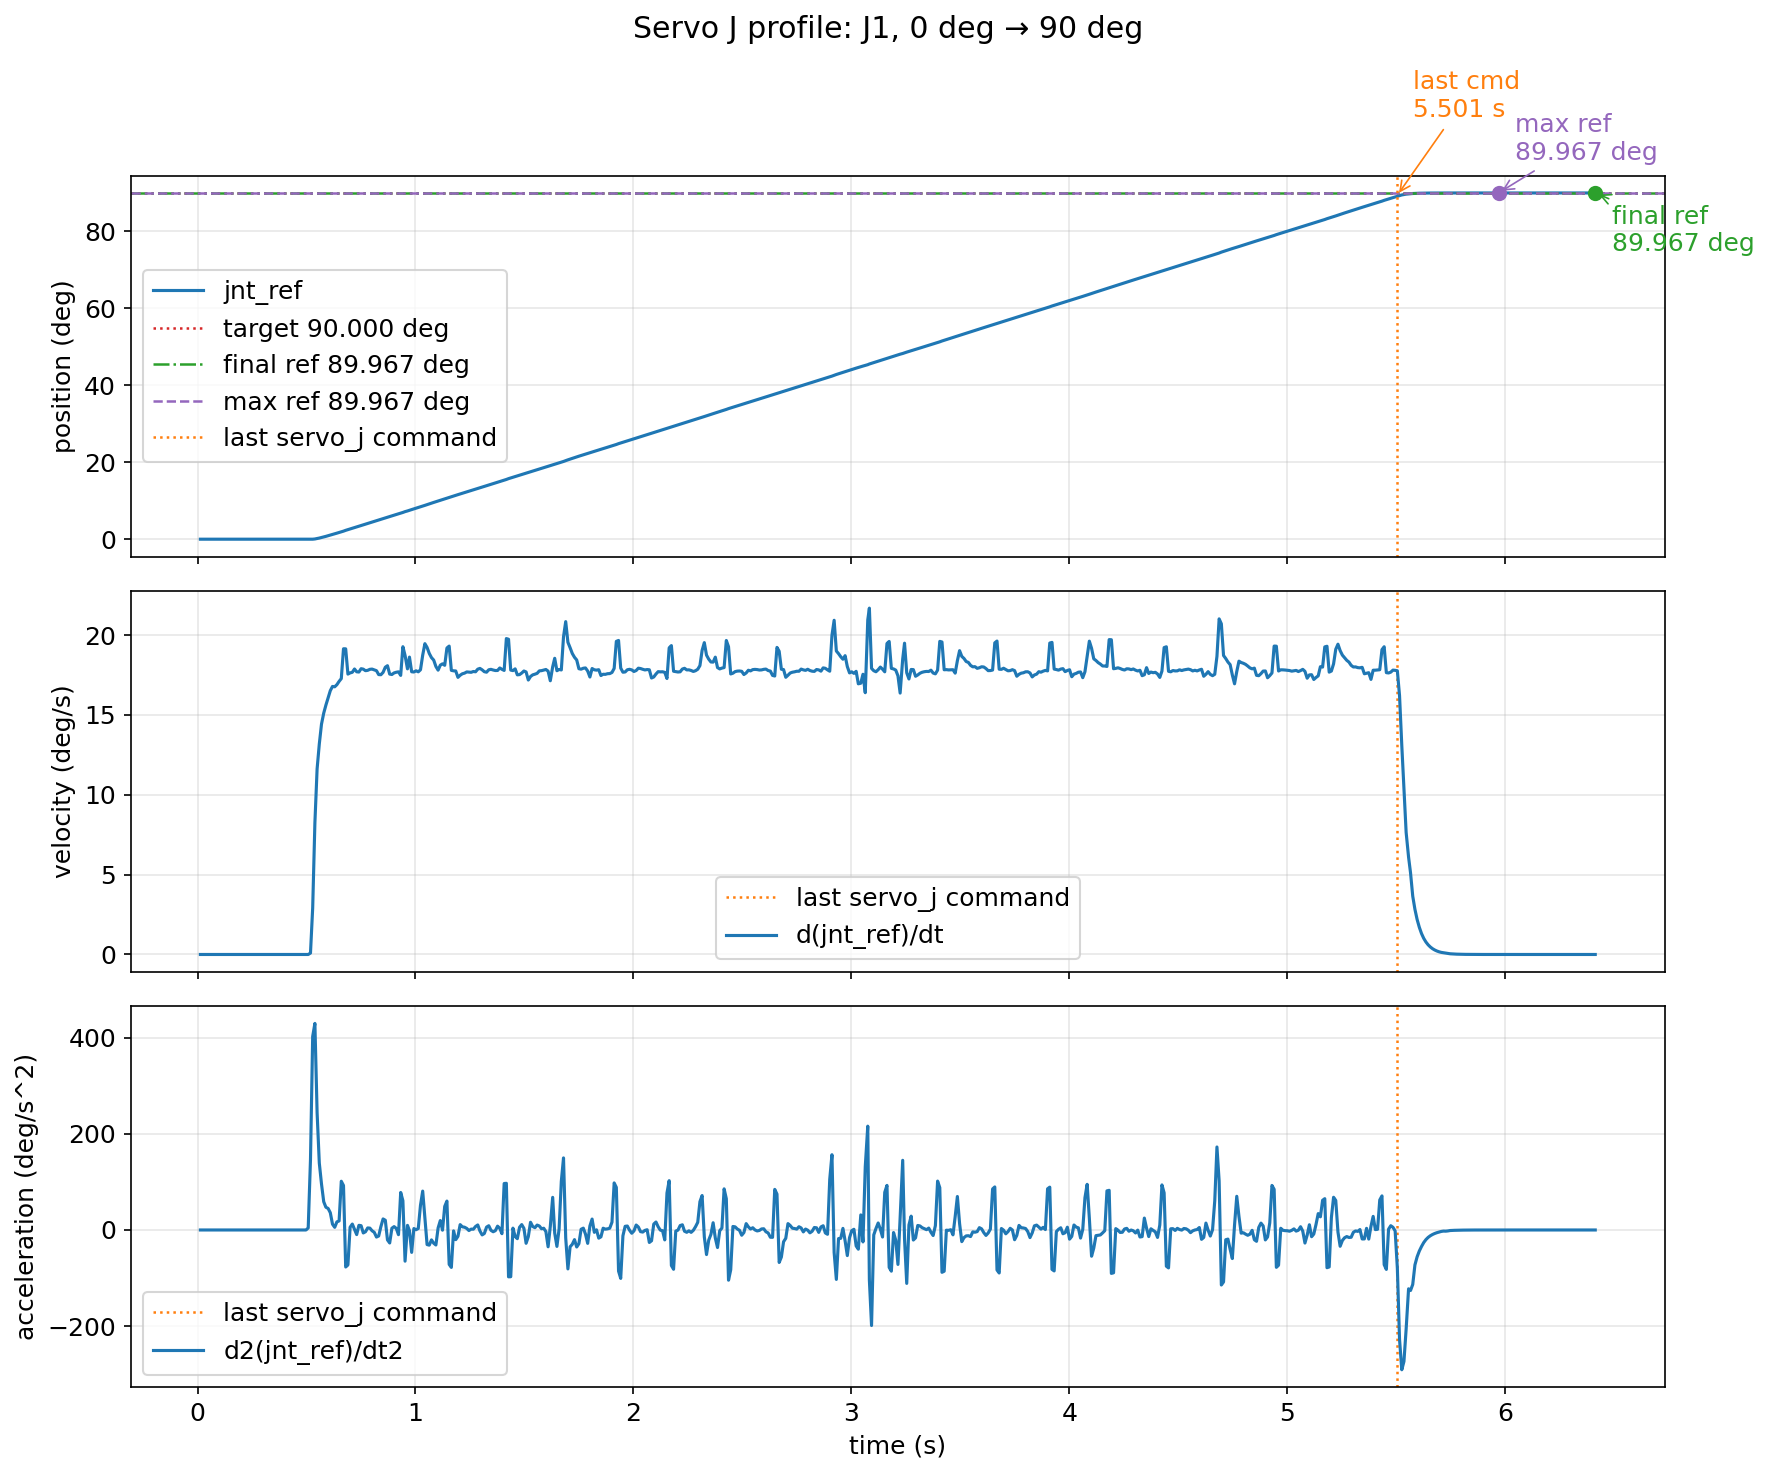

In [50]:
target_angle = END_DEG
final_angle = q_ref[-1]
final_time = t[-1]
max_idx = int(np.nanargmax(q_ref))
max_angle = q_ref[max_idx]
max_time = t[max_idx]
command_time = last_servo_command_time
over_target_indices = np.flatnonzero(q_ref > target_angle)
over_target_idx = int(over_target_indices[0]) if len(over_target_indices) else None
over_target_time = None if over_target_idx is None else t[over_target_idx]
over_target_angle = None if over_target_idx is None else q_ref[over_target_idx]
over_target_dt = None if command_time is None or over_target_time is None else over_target_time - command_time

fig, axes = plt.subplots(3, 1, figsize=(12, 10), facecolor="white", dpi=150, sharex=True)

axes[0].plot(t, q_ref, label="jnt_ref", linewidth=1.5)
axes[0].axhline(target_angle, color="tab:red", linewidth=1.2, linestyle=":", label=f"target {target_angle:.3f} deg")
axes[0].axhline(final_angle, color="tab:green", linewidth=1.2, linestyle="-.", label=f"final ref {final_angle:.3f} deg")
axes[0].axhline(max_angle, color="tab:purple", linewidth=1.2, linestyle="--", label=f"max ref {max_angle:.3f} deg")
axes[0].scatter([final_time], [final_angle], color="tab:green", s=40, zorder=5)
axes[0].scatter([max_time], [max_angle], color="tab:purple", s=40, zorder=5)
axes[0].annotate(
    f"final ref\n{final_angle:.3f} deg",
    xy=(final_time, final_angle),
    xytext=(8, -28),
    textcoords="offset points",
    color="tab:green",
    arrowprops={"arrowstyle": "->", "color": "tab:green", "linewidth": 0.8},
)
axes[0].annotate(
    f"max ref\n{max_angle:.3f} deg",
    xy=(max_time, max_angle),
    xytext=(8, 16),
    textcoords="offset points",
    color="tab:purple",
    arrowprops={"arrowstyle": "->", "color": "tab:purple", "linewidth": 0.8},
)
if command_time is not None:
    for ax in axes:
        ax.axvline(command_time, color="tab:orange", linewidth=1.2, linestyle=":", label="last servo_j command")
    axes[0].annotate(
        f"last cmd\n{command_time:.3f} s",
        xy=(command_time, q_ref[int(np.clip(np.searchsorted(t, command_time, side="left"), 0, len(t) - 1))]),
        xytext=(8, 38),
        textcoords="offset points",
        color="tab:orange",
        arrowprops={"arrowstyle": "->", "color": "tab:orange", "linewidth": 0.8},
    )
if over_target_time is not None:
    for ax in axes:
        ax.axvline(over_target_time, color="tab:cyan", linewidth=1.2, linestyle="--", label=f"first > {target_angle:.3f} deg")
    axes[0].scatter([over_target_time], [over_target_angle], color="tab:cyan", edgecolor="black", s=50, zorder=6)
    dt_text = "" if over_target_dt is None else f"\nΔt from last cmd: {over_target_dt * 1000:.1f} ms"
    axes[0].annotate(
        f"first > {target_angle:.3f} deg\n{over_target_time:.3f} s{dt_text}",
        xy=(over_target_time, over_target_angle),
        xytext=(12, -62),
        textcoords="offset points",
        color="tab:cyan",
        bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "tab:cyan", "alpha": 0.85},
        arrowprops={"arrowstyle": "->", "color": "tab:cyan", "linewidth": 0.8},
    )
    if command_time is not None:
        y_span = target_angle + 0.08 * (np.nanmax(q_ref) - np.nanmin(q_ref) or 1.0)
        axes[0].annotate(
            f"Δt {over_target_dt * 1000:.1f} ms",
            xy=((command_time + over_target_time) / 2, y_span),
            ha="center",
            va="bottom",
            color="tab:cyan",
        )
        axes[0].annotate(
            "",
            xy=(over_target_time, y_span),
            xytext=(command_time, y_span),
            arrowprops={"arrowstyle": "<->", "color": "tab:cyan", "linewidth": 1.0},
        )
axes[0].set_ylabel("position (deg)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, v_ref, label="d(jnt_ref)/dt", linewidth=1.5)
axes[1].set_ylabel("velocity (deg/s)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, a_ref, label="d2(jnt_ref)/dt2", linewidth=1.5)
axes[2].set_xlabel("time (s)")
axes[2].set_ylabel("acceleration (deg/s^2)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle(f"Servo J profile: J{JOINT_INDEX + 1}, {START_DEG:g} deg → {END_DEG:g} deg")
fig.tight_layout()
plt.show()

## 데이터 저장

In [ ]:
import csv
from pathlib import Path

out_dir = Path("servo_j_profile_results")
out_dir.mkdir(exist_ok=True)
out_csv = out_dir / f"servo_j_J{JOINT_INDEX + 1}_{START_DEG:g}_to_{END_DEG:g}.csv"

with out_csv.open("w", newline="", encoding="utf-8-sig") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "t_s",
        "jnt_ref_deg",
        "jnt_ref_vel_deg_s",
        "jnt_ref_acc_deg_s2",
        "last_servo_command_time_s",
    ])
    writer.writeheader()
    for i in range(len(t)):
        writer.writerow({
            "t_s": t[i],
            "jnt_ref_deg": q_ref[i],
            "jnt_ref_vel_deg_s": v_ref[i],
            "jnt_ref_acc_deg_s2": a_ref[i],
            "last_servo_command_time_s": last_servo_command_time,
        })

print(out_csv)